In [2]:
import os
import torch
from torch import nn, optim
from torch.optim import lr_scheduler
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE =", device)

DEVICE = cuda


In [4]:
DATA_DIR = r"C:\Users\mehdi\OneDrive\Bureau\noma_ai_dataset"

TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR   = os.path.join(DATA_DIR, "val")
TEST_DIR  = os.path.join(DATA_DIR, "test")


In [5]:
from torchvision import transforms

input_size = 224

train_tf = transforms.Compose([

    transforms.RandomRotation(degrees=30), 
    
    transforms.RandomResizedCrop(input_size),
    transforms.RandomHorizontalFlip(),
    
    transforms.ColorJitter(
        brightness=0.25,
        contrast=0.25,
        saturation=0.20,
        hue=0.05
    ),
    
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    ),
])

val_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(input_size),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    ),
])

In [6]:
train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
val_ds   = datasets.ImageFolder(VAL_DIR,   transform=val_tf)
test_ds  = datasets.ImageFolder(TEST_DIR,  transform=val_tf)



In [7]:
from collections import Counter
import torch

class_counts = Counter(train_ds.targets)
class_counts = torch.tensor(list(class_counts.values()), dtype=torch.float)

weights = 1.0 / class_counts
weights = weights / weights.sum()

criterion = nn.CrossEntropyLoss(weight=weights.to(device))


In [8]:
BATCH_SIZE = 32

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


In [9]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

In [10]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=15):
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    best_acc = 0.0
    best_state = None

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels) # LabelSmoothing applied here via criterion
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        # --- validation ---
        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                preds = outputs.argmax(1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        val_loss = val_loss / len(val_loader)
        val_acc  = correct / total

        # --- Scheduler Step ---
        # Handle ReduceLROnPlateau specifically
        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_loss)
        else:
            scheduler.step()

        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            best_state = model.state_dict()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: train={train_loss:.4f}, val={val_loss:.4f}, acc={val_acc:.3f}")

    return history, best_state

In [11]:
# 2. Freeze the base (Stage 1: Warm-up)
for param in model.parameters():
    param.requires_grad = False

# 3. REPLACE THE FINAL LAYER (Crucial step to fix the error)
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, 24) # Set this to your 24 classes
)

# 4. Move model to GPU
model = model.to(device)

# 5. Define criterion with 24 weights
criterion = nn.CrossEntropyLoss(weight=weights.to(device), label_smoothing=0.2)

# 6. Unfreeze specific layers for training
for name, param in model.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True

# 7. Initialize optimizer with ONLY the unfrozen parameters
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=7)

# 8. Run training
history_head, state_head = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=7)

Epoch 1: train=2.7503, val=2.6515, acc=0.438
Epoch 2: train=2.4768, val=2.5147, acc=0.487
Epoch 3: train=2.3518, val=2.4264, acc=0.538
Epoch 4: train=2.2424, val=2.3153, acc=0.589
Epoch 5: train=2.1454, val=2.2409, acc=0.628
Epoch 6: train=2.0811, val=2.2251, acc=0.648
Epoch 7: train=2.0358, val=2.1943, acc=0.658


In [12]:
# --- START STAGE 2: FULL FINE-TUNING ---

# 1. Unfreeze the entire model
# This allows gradients to flow through all layers, including early feature extractors
for param in model.parameters():
    param.requires_grad = True

# 2. Re-initialize the optimizer with a much lower learning rate
# A low LR (1e-5) is critical so we don't drastically change pre-trained weights
optimizer = optim.Adam(model.parameters(), lr=1e-5)

# 3. Use ReduceLROnPlateau for Stage 2
# This scheduler will drop the LR further only when validation loss stops improving
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    patience=3, 
    factor=0.1
)

# 4. Run training for more epochs (e.g., 10-15)
# We continue from the current model state achieved in Stage 1
print("\nStarting Stage 2: Fine-tuning the full model...")
history_full, state_full = train_model(
    model, 
    train_loader, 
    val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    epochs=50
)


Starting Stage 2: Fine-tuning the full model...
Epoch 1: train=2.0056, val=2.1859, acc=0.663
Epoch 2: train=1.9985, val=2.1824, acc=0.673
Epoch 3: train=1.9871, val=2.1726, acc=0.666
Epoch 4: train=1.9773, val=2.1673, acc=0.671
Epoch 5: train=1.9734, val=2.1638, acc=0.674
Epoch 6: train=1.9714, val=2.1616, acc=0.676
Epoch 7: train=1.9611, val=2.1614, acc=0.666
Epoch 8: train=1.9613, val=2.1477, acc=0.679
Epoch 9: train=1.9508, val=2.1474, acc=0.680
Epoch 10: train=1.9438, val=2.1517, acc=0.676
Epoch 11: train=1.9346, val=2.1400, acc=0.680
Epoch 12: train=1.9308, val=2.1377, acc=0.684
Epoch 13: train=1.9325, val=2.1341, acc=0.686
Epoch 14: train=1.9234, val=2.1282, acc=0.687
Epoch 15: train=1.9123, val=2.1274, acc=0.686
Epoch 16: train=1.9097, val=2.1267, acc=0.687
Epoch 17: train=1.8994, val=2.1249, acc=0.686
Epoch 18: train=1.8884, val=2.1246, acc=0.686
Epoch 19: train=1.8935, val=2.1169, acc=0.691
Epoch 20: train=1.8814, val=2.1154, acc=0.689
Epoch 21: train=1.8794, val=2.1148, acc=

In [13]:
# Load the best weights from the full fine-tuning stage
model.load_state_dict(state_full)

<All keys matched successfully>

In [14]:
def evaluate_test(model, test_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    print(f"TEST ACCURACY: {acc:.3f}")

evaluate_test(model, test_loader)


TEST ACCURACY: 0.710


Evaluating Test Set: 100%|██████████| 62/62 [00:13<00:00,  4.71it/s]


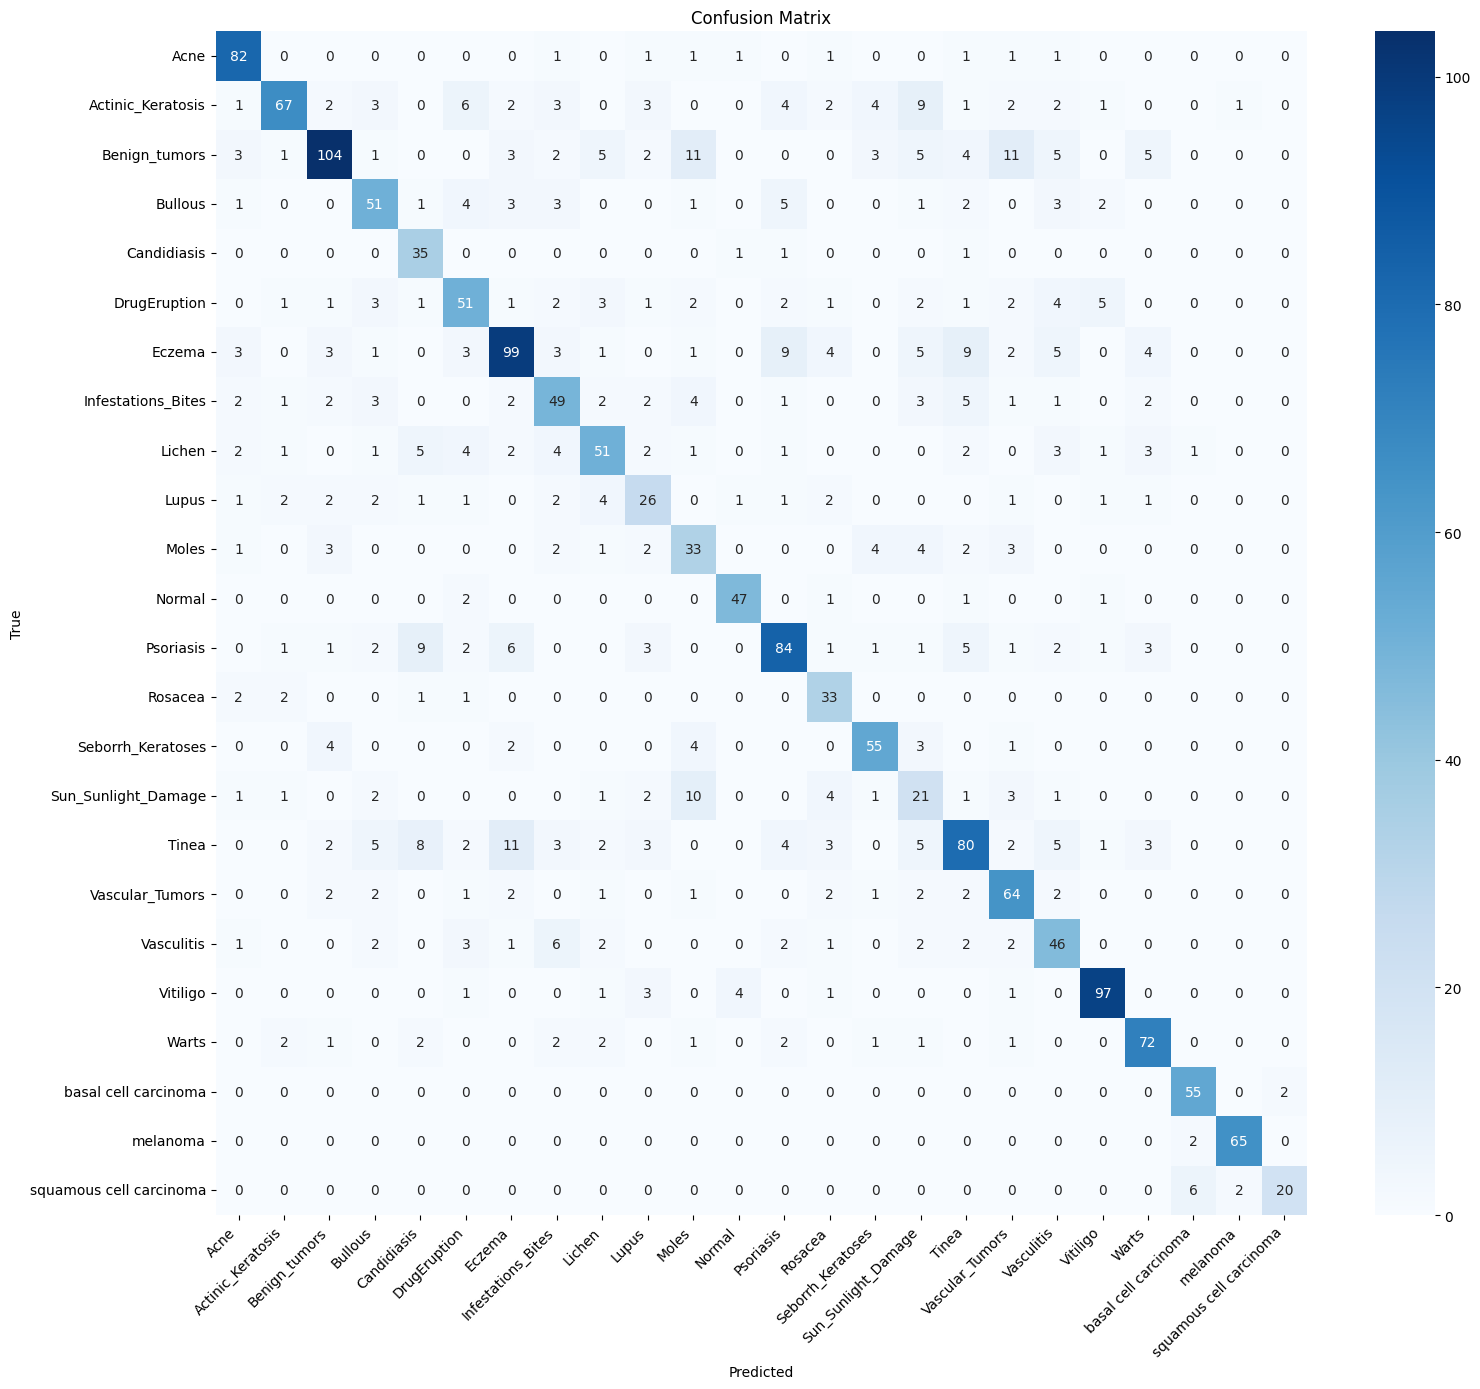


Classification Report:

                         precision    recall  f1-score   support

                   Acne       0.82      0.91      0.86        90
      Actinic_Keratosis       0.85      0.59      0.70       113
          Benign_tumors       0.82      0.63      0.71       165
                Bullous       0.65      0.66      0.66        77
            Candidiasis       0.56      0.92      0.69        38
           DrugEruption       0.63      0.61      0.62        83
                 Eczema       0.74      0.65      0.69       152
     Infestations_Bites       0.60      0.61      0.60        80
                 Lichen       0.67      0.61      0.64        84
                  Lupus       0.52      0.54      0.53        48
                  Moles       0.47      0.60      0.53        55
                 Normal       0.87      0.90      0.89        52
              Psoriasis       0.72      0.68      0.70       123
                Rosacea       0.59      0.85      0.69        39

In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm import tqdm

# --- STEP 1: DEFINE CLASS NAMES ---
# Attempt to get class names from the dataset. 
# If your dataset object is named differently (e.g., 'test_dataset'), update it here.
try:
    class_names = train_loader.dataset.classes
except AttributeError:
    # Fallback: Manually define if dataset.classes isn't available
    class_names = [f"Class {i}" for i in range(24)] 

model.eval()
all_labels = []
all_preds  = []

# --- STEP 2: EVALUATE WITH PROGRESS BAR ---
with torch.no_grad():
    # Adding tqdm here shows you the progress of the evaluation
    for images, labels in tqdm(test_loader, desc="Evaluating Test Set"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

# --- STEP 3: CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(16, 14)) # Increased size for 24 classes
sns.heatmap(
    cm, 
    annot=True,      # Set to True to see exact numbers in the boxes
    fmt='d',         # Integer format
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# --- STEP 4: CLASSIFICATION REPORT ---
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

In [18]:
torch.save(model.state_dict(), "best_resnet_noma.pt")
